In [1]:
# Install Required Libraries
%pip install tensorflow pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [6]:
# Load Weather Dataset

data = pd.read_csv("weather_data.csv")

# Display First 5 Rows
print(data.head())

   Day  City1_Temp  City2_Temp  City3_Temp  TargetCity_Temp
0    1       26.12       28.69       22.03            25.63
1    2       26.10       29.23       23.13            26.62
2    3       27.48       28.63       25.24            26.66
3    4       28.92       29.95       25.86            28.56
4    5       27.69       30.40       25.91            27.71


In [7]:
# Select Input Features and Target

X_data = data[[
    "City1_Temp",
    "City2_Temp",
    "City3_Temp"
]].values

y_data = data["TargetCity_Temp"].values.reshape(-1,1)

# Normalize Data

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_data)

y_scaled = scaler_y.fit_transform(y_data)

In [8]:
# Create Sequences for LSTM

time_step = 5

X = []
y = []

for i in range(len(X_scaled)-time_step):

    X.append(X_scaled[i:i+time_step])

    y.append(y_scaled[i+time_step])

X = np.array(X)
y = np.array(y)

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (145, 5, 3)
Output Shape: (145, 1)


In [9]:
# Build LSTM Model

model = Sequential()

model.add(LSTM(
    50,
    activation='tanh',
    input_shape=(time_step,3)
))

model.add(Dense(1))

# Compile Model

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Model Summary

model.summary()

/opt/intel/oneapi/intelpython/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,851 (42.39 KB)

 Trainable params: 10,851 (42.39 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train Model

history = model.fit(
    X,
    y,
    epochs=50,
    batch_size=8,
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1705
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0176 
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0117 
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0097 
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084     
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0081 
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076 
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0078 
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0078 
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0075 
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0073 
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0075 
Epoch 13/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0073 
Epoch 14/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076 
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0072 
E

In [11]:
# Predict Future Weather

predictions = model.predict(X)

# Convert Predictions Back to Original Scale

predictions = scaler_y.inverse_transform(predictions)

actual = scaler_y.inverse_transform(y)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step 


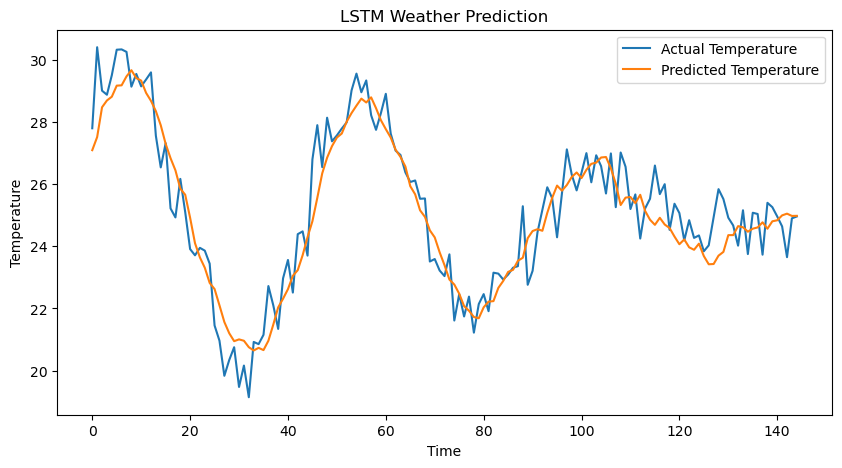

In [12]:
# Plot Results

plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual Temperature")

plt.plot(predictions, label="Predicted Temperature")

plt.xlabel("Time")

plt.ylabel("Temperature")

plt.title("LSTM Weather Prediction")

plt.legend()

plt.show()